# Airline Hub Optimization Project

Problem: How can airlines choose hub airports to minimize total travel distance and improve network efficiency?

Goal: From the top 30 airports in the US, choose the best 5 hubs and assign each airport to one hub to minimize weighted distance. 

In [2]:
!pip install -q pyomo

# Install solver for Google Colab
import sys
import os

if 'google.colab' in sys.modules:
    !pip install idaes-pse --pre
    !idaes get-extensions --to ./bin
    os.environ['PATH'] += ':bin'

# Import packages
import numpy as np
import pandas as pd
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import folium

from math import radians, sin, cos, sqrt, atan2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Load Data

In [3]:
airports_url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/airports.dat"
routes_url = "https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat"

airports_cols = ["airport_id", "name", "city", "country", "iata", "icao", "lat", "lon", "altitude", "timezone", "dst", "tz", "type", "source"]
routes_cols = ["airline", "airline_id", "source_airport", "source_airport_id", "dest_airport", "dest_airport_id", "codeshare", "stops", "equipment"]

airports = pd.read_csv(airports_url, header=None, names=airports_cols)
routes = pd.read_csv(routes_url, header=None, names=routes_cols)

print("Airports data shape:", airports.shape)
print("Routes data shape:", routes.shape)

Airports data shape: (7698, 14)
Routes data shape: (67663, 9)


Clean Airport Data

In [4]:
airports["airport_id"] = pd.to_numeric(airports["airport_id"], errors="coerce")

us_airports = airports[
    (airports["country"] == "United States") &
    (airports["iata"].notna()) &
    (airports["lat"].notna() & airports["lon"].notna())
    ].copy()

us_airports = us_airports[["airport_id", "name", "city", "country", "iata", "lat", "lon"]]
us_airports["airport_id"] = us_airports["airport_id"].astype(int)

print("Num US airports: ", len(us_airports))
us_airports.head()


Num US airports:  1512


,airport_id,name,city,country,iata,lat,lon
3212,3411,Barter Island LRRS Airport,Barter Island,United States,BTI,70.134003,-143.582001
3213,3412,Wainwright Air Station,Fort Wainwright,United States,\N,70.613403,-159.860001
3214,3413,Cape Lisburne LRRS Airport,Cape Lisburne,United States,LUR,68.875099,-166.110001
3215,3414,Point Lay LRRS Airport,Point Lay,United States,PIZ,69.732903,-163.005005
3216,3415,Hilo International Airport,Hilo,United States,ITO,19.721399,-155.048004


Clean Routes Data

In [5]:
routes["source_airport_id"] = pd.to_numeric(routes["source_airport_id"], errors="coerce")
routes["dest_airport_id"] = pd.to_numeric(routes["dest_airport_id"], errors="coerce")
routes["stops"] = pd.to_numeric(routes["stops"], errors="coerce")

us_ids = set(us_airports["airport_id"])

us_routes = routes[
    routes["source_airport_id"].isin(us_ids) &
    routes["dest_airport_id"].isin(us_ids) &
    (routes["stops"] == 0)
    ].copy()

print("Number of direct US routes: ", len(us_routes))
us_routes.head()


Number of direct US routes:  10512


,airline,airline_id,source_airport,source_airport_id,dest_airport,dest_airport_id,codeshare,stops,equipment
172,2O,146,ADQ,3531.0,KLN,7162.0,NaN,0,BNI
177,2O,146,KLN,7162.0,KYK,7161.0,NaN,0,BNI
260,3E,10739,BRL,5726.0,ORD,3830.0,NaN,0,CNC
261,3E,10739,BRL,5726.0,STL,3678.0,NaN,0,CNC
262,3E,10739,DEC,4042.0,ORD,3830.0,NaN,0,CNC


Number of airports required for the desired coverage

In [42]:
source_counts = us_routes["source_airport_id"].value_counts()
dest_counts = us_routes["dest_airport_id"].value_counts()
activity = source_counts.add(dest_counts, fill_value=0).reset_index()
activity.columns = ["airport_id", "route_count"]
activity = activity.sort_values("route_count", ascending=False)

n = 0
step = 1
target_percentage = 0.25

n_values = []
coverage_values = []

while True:
    topn = activity.head(n)
    top_ids = set(topn["airport_id"])

    covered_routes = us_routes[
    (us_routes["source_airport_id"].isin(top_ids)) &
    (us_routes["dest_airport_id"].isin(top_ids))
]

    coverage = len(covered_routes) / len(us_routes)

    n_values.append(n)
    coverage_values.append(coverage)

    print(f"\nTop {n} airports:")
    print(f"Coverage: {coverage:.2%}")

    merged = topn.merge(
        us_airports[["airport_id", "name", "city", "iata"]],
        on="airport_id"
    )
    print(merged[["name", "city", "iata", "route_count"]])
    
    if coverage >= target_percentage:
        print(f"\nReached {target_percentage*100:.0f}% coverage at n = {n}")
        break

    n += step

num_airports = n
print(num_airports)


Top 0 airports:
Coverage: 0.00%
Empty DataFrame
Columns: [name, city, iata, route_count]
Index: []

Top 1 airports:
Coverage: 0.00%
                                               name     city iata  route_count
0  Hartsfield Jackson Atlanta International Airport  Atlanta  ATL       1496.0

Top 2 airports:
Coverage: 0.37%
                                               name     city iata  route_count
0  Hartsfield Jackson Atlanta International Airport  Atlanta  ATL       1496.0
1              Chicago O'Hare International Airport  Chicago  ORD        752.0

Top 3 airports:
Coverage: 0.65%
                                               name               city iata  \
0  Hartsfield Jackson Atlanta International Airport            Atlanta  ATL   
1              Chicago O'Hare International Airport            Chicago  ORD   
2           Dallas Fort Worth International Airport  Dallas-Fort Worth  DFW   

   route_count  
0       1496.0  
1        752.0  
2        657.0  

Top 4 airports:
Cove

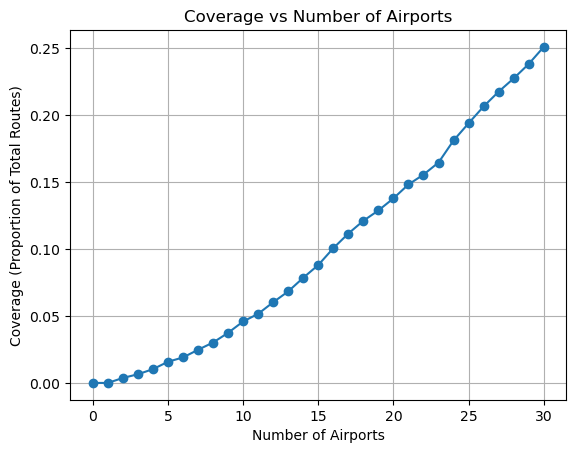

In [ ]:
plt.figure()
plt.plot(n_values, coverage_values, marker='o')

plt.xlabel("Number of Airports")
plt.ylabel("Coverage")
plt.title("Coverage vs Number of Airports")

plt.grid(True)
plt.show()

Find top N airports

In [44]:
source_counts = us_routes["source_airport_id"].value_counts()
dest_counts = us_routes["dest_airport_id"].value_counts()

activity = source_counts.add(dest_counts, fill_value=0).reset_index()
activity.columns = ["airport_id", "route_count"]

topn = activity.sort_values("route_count", ascending=False).head(num_airports).copy()

topn_airports = us_airports.merge(topn, on="airport_id", how="inner").copy()
topn_airports = topn_airports.sort_values("route_count", ascending=False).reset_index(drop=True)

print(f"Top {n} Airports")
topn_airports[["airport_id", "iata", "city", "route_count"]]


Top 30 Airports


,airport_id,iata,city,route_count
0,3682,ATL,Atlanta,1496.0
1,3830,ORD,Chicago,752.0
2,3670,DFW,Dallas-Fort Worth,657.0
3,3751,DEN,Denver,653.0
4,3484,LAX,Los Angeles,606.0
5,3876,CLT,Charlotte,477.0
6,3462,PHX,Phoenix,441.0
7,3752,PHL,Philadelphia,412.0
8,3877,LAS,Las Vegas,404.0
9,3858,MSP,Minneapolis,380.0


Create airport weights

Normalized weights using ratio of routes to total routes

In [45]:
weight = (topn_airports["route_count"]/topn_airports["route_count"].sum())
topn_airports["weight"] = weight

topn_airports[["iata", "city", "route_count", "weight"]]

,iata,city,route_count,weight
0,ATL,Atlanta,1496.0,0.127700
1,ORD,Chicago,752.0,0.064191
2,DFW,Dallas-Fort Worth,657.0,0.056082
3,DEN,Denver,653.0,0.055741
4,LAX,Los Angeles,606.0,0.051729
5,CLT,Charlotte,477.0,0.040717
6,PHX,Phoenix,441.0,0.037644
7,PHL,Philadelphia,412.0,0.035169
8,LAS,Las Vegas,404.0,0.034486
9,MSP,Minneapolis,380.0,0.032437


Distance function

In [46]:
def haversine(lat1, lon1, lat2, lon2):
  R = 3958.8 #earth radius in miles

  lat1 = radians(lat1)
  lon1 = radians(lon1)
  lat2 = radians(lat2)
  lon2 = radians(lon2)

  dlat = lat2 - lat1
  dlon = lon2 - lon1

  a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
  c = 2 * atan2(sqrt(a), sqrt(1-a))

  return R*c


Build distance matrix

In [47]:
from IPython.display import clear_output
clear_output()

airport_ids = topn_airports["airport_id"].tolist()
airport_lookup = topn_airports.set_index("airport_id")[["iata", "city", "lat", "lon", "weight"]].to_dict("index")

distance_m = {}
for i in airport_ids:
  for j in airport_ids:
    lat1 = airport_lookup[i]["lat"]
    lon1 = airport_lookup[i]["lon"]
    lat2 = airport_lookup[j]["lat"]
    lon2 = airport_lookup[j]["lon"]
    distance_m[(i,j)] = round(haversine(lat1, lon1, lat2, lon2), 2)

list(distance_m.items())[:10]

[((3682, 3682), 0.0),
 ((3682, 3830), 606.67),
 ((3682, 3670), 729.83),
 ((3682, 3751), 1197.16),
 ((3682, 3484), 1942.29),
 ((3682, 3876), 226.53),
 ((3682, 3462), 1583.94),
 ((3682, 3752), 665.86),
 ((3682, 3877), 1742.86),
 ((3682, 3858), 907.04)]

In [48]:
import pyomo.environ as pyo

def solve_model(p_value, data):
    model = pyo.ConcreteModel()
    
    # Sets
    model.I = pyo.Set(initialize=data["I"])
    model.J = pyo.Set(initialize=data["J"])
    
    # Parameters
    model.w = pyo.Param(model.I, initialize=data["w"])
    model.d = pyo.Param(model.I, model.J, initialize=data["d"])
    
    # Decision variables
    model.x = pyo.Var(model.J, domain=pyo.Binary)
    model.y = pyo.Var(model.I, model.J, domain=pyo.Binary)
    
    # Number of hubs
    model.p = pyo.Param(initialize=p_value)
    
    # Objective
    def obj_rule(model):
        return sum(model.w[i] * model.d[i,j] * model.y[i,j]
                   for i in model.I for j in model.J)
    model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)
    
    # Constraints
    def assign_rule(model, i):
        return sum(model.y[i,j] for j in model.J) == 1
    model.assign = pyo.Constraint(model.I, rule=assign_rule)
    
    def hub_link_rule(model, i, j):
        return model.y[i,j] <= model.x[j]
    model.hub_link = pyo.Constraint(model.I, model.J, rule=hub_link_rule)
    
    def p_hubs_rule(model):
        return sum(model.x[j] for j in model.J) == model.p
    model.p_hubs = pyo.Constraint(rule=p_hubs_rule)
    
    # Solve
    solver = pyo.SolverFactory("cbc")
    results = solver.solve(model)
    
    # Return objective value
    if (results.solver.status == pyo.SolverStatus.ok and
        results.solver.termination_condition == pyo.TerminationCondition.optimal):
        return pyo.value(model.obj)
    else:
        return None

Determine optimal number of hubs using the elbow method

In [49]:
p_values = range(len(airport_ids)+1)
objective_values = []
weight_m = {i: airport_lookup[i]["weight"] for i in airport_ids}

for p in p_values:
    obj_val = solve_model(p, {
        "I": airport_ids,
        "J": airport_ids,
        "w": weight_m,
        "d": distance_m
    })
    objective_values.append(obj_val)
    print(f"p = {p}, objective = {obj_val}")

model.name="unknown";
    - termination condition: infeasible
    - message from solver: <undefined>
p = 0, objective = None
p = 1, objective = 814.8186530089629
p = 2, objective = 479.41231754161333
p = 3, objective = 356.6157737942808
p = 4, objective = 276.162576184379
p = 5, objective = 223.87674178403756
p = 6, objective = 188.8654579598805
p = 7, objective = 153.2930704225352
p = 8, objective = 118.28178659837815
p = 9, objective = 104.37908749466496
p = 10, objective = 92.48388647033717
p = 11, objective = 81.66029278702518
p = 12, objective = 72.4366641058472
p = 13, objective = 63.58976355100299
p = 14, objective = 54.96297055057619
p = 15, objective = 46.37706017925736
p = 16, objective = 38.33933760136577
p = 17, objective = 31.34083994878361
p = 18, objective = 24.553029449423818
p = 19, objective = 19.048215108834828
p = 20, objective = 14.320729833546736
p = 21, objective = 9.715593683311994
p = 22, objective = 6.5385702091335896
p = 23, objective = 4.199241143832693
p = 

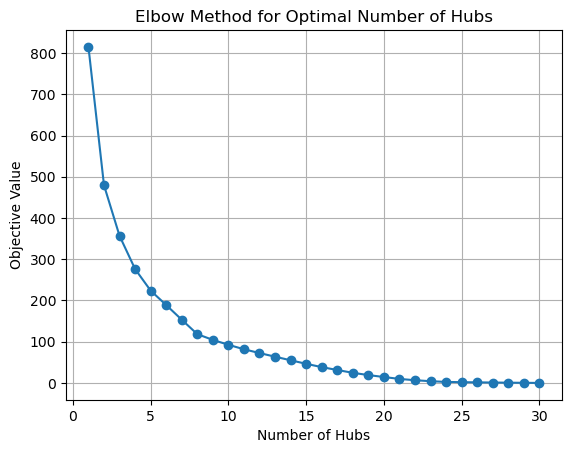

In [50]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(p_values, objective_values, marker='o')
plt.xlabel("Number of Hubs")
plt.ylabel("Objective Value")
plt.title("Elbow Method for Optimal Number of Hubs")
plt.grid(True)
plt.show()

Building the model

In [51]:
model = pyo.ConcreteModel()
model.clear()

# sets
model.I = pyo.Set(initialize=airport_ids)
model.J = pyo.Set(initialize=airport_ids)

# parameters
weight_m = {i: airport_lookup[i]["weight"] for i in airport_ids}
p_hubs = 5

model.d = pyo.Param(model.I, model.J, initialize=distance_m, default=float("inf"))
model.w = pyo.Param(model.I, initialize=weight_m)
model.p = pyo.Param(initialize=p_hubs)

# decision variables
model.x = pyo.Var(model.J, domain=pyo.Binary)
model.y = pyo.Var(model.I, model.J, domain=pyo.Binary)

# constraints
# each airport is assigned to exactly one hub
def assign_rule(model, i):
    return sum(model.y[i, j] for j in model.J) == 1
model.AssignConstraint = pyo.Constraint(model.I, rule=assign_rule)

# can only assign airport i to airport j if j is a hub
def open_hub_rule(model, i, j):
    return model.y[i, j] <= model.x[j]
model.OpenHubConstraint = pyo.Constraint(model.I, model.J, rule=open_hub_rule)

num_of_hubs = 5

def num_hubs_rule(model):
    return sum(model.x[j] for j in model.J) == num_of_hubs
model.NumHubsConstraint = pyo.Constraint(rule=num_hubs_rule)


In [15]:
conda install -c conda-forge coincbc

/opt/anaconda3/lib/python3.12/site-packages/conda/base/context.py:201: FutureWarning: Adding 'defaults' to channel list implicitly is deprecated and will be removed in 25.3. 

To remove this warning, please choose a default channel explicitly with conda's regular configuration system, e.g. by adding 'defaults' to the list of channels:

  conda config --add channels defaults

For more information see https://docs.conda.io/projects/conda/en/stable/user-guide/configuration/use-condarc.html

  deprecated.topic(
Retrieving notices: done
/opt/anaconda3/lib/python3.12/site-packages/conda/base/context.py:201: FutureWarning: Adding 'defaults' to channel list implicitly is deprecated and will be removed in 25.3. 

To remove this warning, please choose a default channel explicitly with conda's regular configuration system, e.g. by adding 'defaults' to the list of channels:

  conda config --add channels defaults

For more information see https://docs.conda.io/projects/conda/en/stable/user-guide/c

In [52]:
# objective function
def obj_rule(model):
   return sum(model.w[i] * model.d[i, j] * model.y[i, j]
              for i in model.I for j in model.J)

model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)
model.constraints = pyo.ConstraintList()

solver = pyo.SolverFactory("cbc")
results = solver.solve(model)

print("Solver status: ", results.solver.status)
print("Solver termination condition: ", results.solver.termination_condition)

Solver status:  ok
Solver termination condition:  optimal


Get the results

In [53]:
if results.solver.status == pyo.SolverStatus.ok:
   selected_hubs = [j for j in model.J if pyo.value(model.x[j]) > 0.5]

   assignments = {}
   for i in model.I:
       for j in model.J:
           if pyo.value(model.y[i, j]) > 0.5:
               assignments[i] = j

   objective_value = pyo.value(model.obj)

   print("Selected hubs:")
   for j in selected_hubs:
       print(airport_lookup[j]["iata"], "-", airport_lookup[j]["city"])

   print("\nObjective value:", objective_value)

else:
   print("Solver did not find an optimal solution.")


Selected hubs:
ATL - Atlanta
ORD - Chicago
DFW - Dallas-Fort Worth
PHL - Philadelphia
LAS - Las Vegas

Objective value: 223.87674178403756


Tables for the results and hubs

In [54]:
# results table
results_df = []

for i in model.I:
   assigned_hub = assignments[i]

   results_df.append({
       "airport_id": i,
       "airport_iata": airport_lookup[i]["iata"],
       "airport_city": airport_lookup[i]["city"],
       "hub_id": assigned_hub,
       "hub_iata": airport_lookup[assigned_hub]["iata"],
       "hub_city": airport_lookup[assigned_hub]["city"],
       "distance_to_hub_miles": distance_m[(i, assigned_hub)],
       "airport_weight": weight_m[i]
   })

results_df = pd.DataFrame(results_df)
results_df = results_df.sort_values(["hub_iata", "airport_iata"]).reset_index(drop=True)
results_df


,airport_id,airport_iata,airport_city,hub_id,hub_iata,hub_city,distance_to_hub_miles,airport_weight
0,3682,ATL,Atlanta,3682,ATL,Atlanta,0.00,0.127700
1,3876,CLT,Charlotte,3682,ATL,Atlanta,226.53,0.040717
2,3533,FLL,Fort Lauderdale,3682,ATL,Atlanta,581.88,0.019292
3,3878,MCO,Orlando,3682,ATL,Atlanta,404.35,0.029279
4,3576,MIA,Miami,3682,ATL,Atlanta,595.94,0.020657
5,3861,MSY,New Orleans,3682,ATL,Atlanta,424.76,0.020828
6,3646,TPA,Tampa,3682,ATL,Atlanta,406.97,0.021596
7,3670,DFW,Dallas-Fort Worth,3670,DFW,Dallas-Fort Worth,0.00,0.056082
8,3550,IAH,Houston,3670,DFW,Dallas-Fort Worth,224.70,0.024499
9,3751,DEN,Denver,3877,LAS,Las Vegas,627.20,0.055741


In [39]:
hub_summary = (
   results_df.groupby(["hub_iata", "hub_city"])
   .agg(
       airports_assigned=("airport_iata", "count"),
       total_weight=("airport_weight", "sum"),
       avg_distance_to_hub=("distance_to_hub_miles", "mean"),
       max_distance_to_hub=("distance_to_hub_miles", "max")
   )
   .reset_index()
   .sort_values("total_weight", ascending=False)
)

hub_summary

,hub_iata,hub_city,airports_assigned,total_weight,avg_distance_to_hub,max_distance_to_hub
3,LAS,Las Vegas,11,0.215561,348.427273,627.20
5,ORD,Chicago,12,0.187269,220.701667,402.03
6,PHL,Philadelphia,11,0.181782,153.793636,336.94
0,ATL,Atlanta,5,0.164662,239.276000,424.76
1,DFW,Dallas-Fort Worth,7,0.100013,156.664286,247.50
4,MCO,Orlando,8,0.094989,111.925000,192.61
7,SEA,Seattle,3,0.042306,524.790000,1445.10
2,HNL,Honolulu,2,0.013419,50.315000,100.63


Visualizations

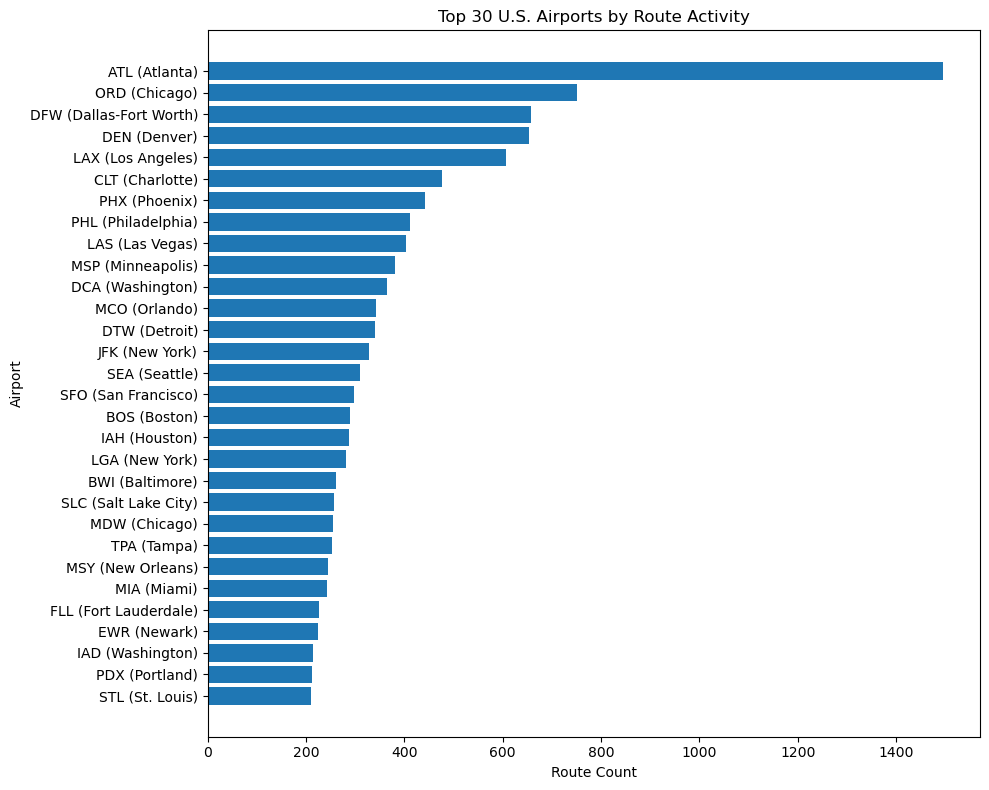

In [55]:
# top 30 airports by route count
plot_df = topn_airports.sort_values("route_count", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df["iata"] + " (" + plot_df["city"] + ")", plot_df["route_count"])
plt.xlabel("Route Count")
plt.ylabel("Airport")
plt.title(f"Top {n} U.S. Airports by Route Activity")
plt.tight_layout()
plt.show()


In [56]:
# hub and spoke map
center_lat = topn_airports["lat"].mean()
center_lon = topn_airports["lon"].mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=4)

# Plot all airports
for _, row in topn_airports.iterrows():
   folium.CircleMarker(
       location=[row["lat"], row["lon"]],
       radius=5,
       color="blue",
       fill=True,
       fill_opacity=0.7,
       popup=f'{row["iata"]} - {row["city"]}'
   ).add_to(m)

# Plot selected hubs
for j in selected_hubs:
   hub = airport_lookup[j]
   folium.Marker(
       location=[hub["lat"], hub["lon"]],
       popup=f'HUB: {hub["iata"]} - {hub["city"]}',
       icon=folium.Icon(color="red", icon="star")
   ).add_to(m)

# Draw assignment lines
for i, j in assignments.items():
   airport = airport_lookup[i]
   hub = airport_lookup[j]

   folium.PolyLine(
       locations=[
           [airport["lat"], airport["lon"]],
           [hub["lat"], hub["lon"]]
       ],
       color="gray",
       weight=1.5,
       opacity=0.5
   ).add_to(m)

m


In [57]:
# finals hubs info
selected_hubs_df = topn_airports[topn_airports["airport_id"].isin(selected_hubs)][
   ["airport_id", "iata", "city", "route_count", "weight"]
].sort_values("route_count", ascending=False)

print(selected_hubs_df["weight"]*selected_hubs_df["route_count"])

selected_hubs_df


0    191.038498
1     48.271788
2     36.845839
7     14.489458
8     13.932224
dtype: float64


,airport_id,iata,city,route_count,weight
0,3682,ATL,Atlanta,1496.0,0.127700
1,3830,ORD,Chicago,752.0,0.064191
2,3670,DFW,Dallas-Fort Worth,657.0,0.056082
7,3752,PHL,Philadelphia,412.0,0.035169
8,3877,LAS,Las Vegas,404.0,0.034486
